In [1]:
library(ggplot2)
library(readr)
library(dplyr)
library(tidyr)
library(cowplot)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [9]:
org_tis <- read_csv("/project/onibasu/Josh/glimpse2/4.4concordance_allvsall/concordance_allvsall.csv")
org_tis$Concordance <- as.numeric(org_tis$Concordance)

Rows: 196 Columns: 3
── Column specification ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Organoid, Tissue
dbl (1): Concordance

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [10]:
# Org vs tissue - flag matched pairs by position
org_order <- levels(factor(org_tis$Organoid, 
                            levels = unique(org_tis$Organoid)))
tis_order <- levels(factor(org_tis$Tissue,   
                            levels = unique(org_tis$Tissue)))

org_tis$Organoid <- factor(org_tis$Organoid, levels = org_order)
org_tis$Tissue   <- factor(org_tis$Tissue,   levels = tis_order)

# Flag matched pairs (same position in both files)
org_tis$matched <- mapply(function(o, t) {
    which(org_order == as.character(o)) == which(tis_order == as.character(t))
}, org_tis$Organoid, org_tis$Tissue)

In [11]:
all_vals <- c(org_tis$Concordance)
val_min  <- floor(min(all_vals, na.rm=TRUE) * 1000) / 1000
val_max  <- 1.0
val_mid  <- (val_min + val_max) / 2

cat("Concordance range:", val_min, "-", val_max, "\n")
cat("Midpoint:", val_mid, "\n")

Concordance range: 0.928 - 1 
Midpoint: 0.964 


In [14]:
plot_heatmap <- function(df, x_col, y_col, title, 
                          show_diagonal_box = FALSE,
                          matched_col = NULL) {
    
    p <- ggplot(df, aes_string(x = x_col, y = y_col, fill = "Concordance")) +
        geom_tile(color = "white", linewidth = 0.3) +
        geom_text(aes(label = sprintf("%.3f", Concordance)),
                  size = 2.5, color = "black") +
        scale_fill_gradient2(
            low      = "#6E896E",
            mid      = 'white',
            high     = '#5c53a5',
            midpoint = val_mid,
            limits   = c(val_min, val_max),
            na.value = "grey80",
            name     = "Concordance"
        ) +
        theme_minimal(base_size = 11) +
        theme(
            axis.text.x   = element_text(angle = 45, hjust = 1, 
                                          face = "bold", size = 9),
            axis.text.y   = element_text(face = "bold", size = 9),
            panel.grid    = element_blank(),
            plot.title    = element_text(hjust = 0.5, face = "bold", size = 12),
            legend.position = "right",
            legend.title  = element_text(size = 9),
            legend.text   = element_text(size = 8)
        ) +
        labs(title = title, x = "", y = "")
    
    # Add black border around matched pairs
    if (!is.null(matched_col)) {
        p <- p + geom_tile(
            data = df[df[[matched_col]], ],
            color = "black", linewidth = 1.2, fill = NA
        )
    }
    
    return(p)
}

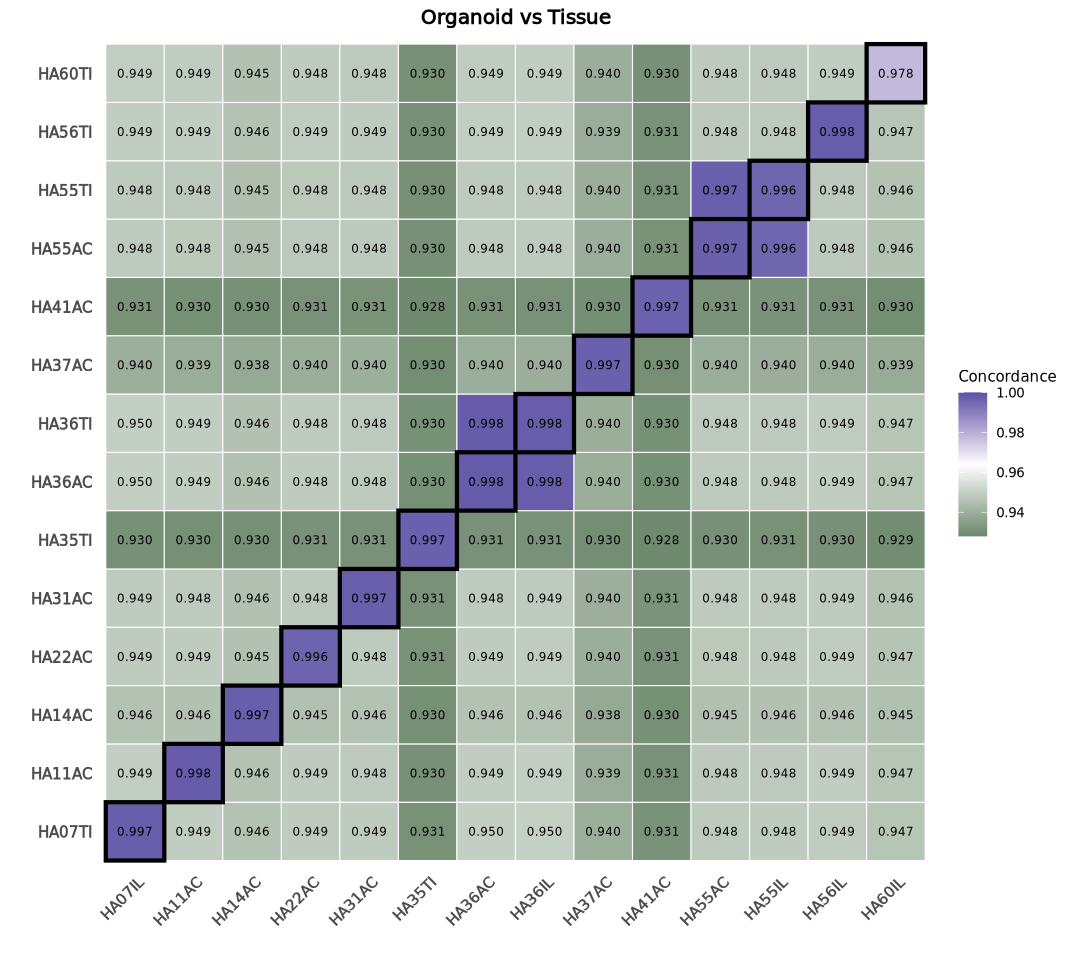

In [15]:
options(repr.plot.width = 9, repr.plot.height = 8)

p1 <- plot_heatmap(
    df           = org_tis,
    x_col        = "Organoid",
    y_col        = "Tissue",
    title        = "Organoid vs Tissue",
    matched_col  = "matched"
)
print(p1)